## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('./shopping_trends.csv')
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [4]:
# TODO: drop the Customer ID column  
df1 = df.drop(columns='Customer ID')
df1

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [5]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [6]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [7]:
# TODO: check duplicate rows with df.duplicated().sum()
print(df.duplicated().sum())

0


In [8]:
# TODO: univariate — describe numeric columns
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [9]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
df1
male_df = df1[df1['Gender'] == 'Male']
female_df = df1[df1['Gender'] == 'Female']
display(male_df)
display(female_df)

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647,60,Male,Shoes,Footwear,58,South Carolina,M,Red,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,25,Debit Card,Annually
2648,51,Male,Pants,Clothing,84,Illinois,M,Gray,Spring,3.9,No,Venmo,Next Day Air,No,No,14,PayPal,Bi-Weekly
2649,23,Male,Gloves,Accessories,21,Minnesota,M,Magenta,Fall,3.9,No,Credit Card,Store Pickup,No,No,14,Bank Transfer,Fortnightly
2650,20,Male,Socks,Clothing,35,Oregon,L,Maroon,Summer,4.2,No,PayPal,Standard,No,No,46,Credit Card,Every 3 Months


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2652,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly
2653,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months
2654,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Debit Card,Next Day Air,No,No,4,PayPal,Annually
2655,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Credit Card,Standard,No,No,2,Credit Card,Fortnightly
2656,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


## **EDA**

### **Item Purchased**

In [10]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
print('Sản phẩm được bán nhiều nhất ở nam giới: \n', male_df['Item Purchased'].value_counts().reset_index().head(1))
print('Sản phẩm được bán nhiều nhất ở nữ giới: \n', female_df['Item Purchased'].value_counts().reset_index().head(1))
print('Sản phầm được bán nhiều nhất: \n', df1['Item Purchased'].value_counts().reset_index().head(1))
print(plt.title)

Sản phẩm được bán nhiều nhất ở nam giới: 
   Item Purchased  count
0          Pants    123
Sản phẩm được bán nhiều nhất ở nữ giới: 
   Item Purchased  count
0         Blouse     66
Sản phầm được bán nhiều nhất: 
   Item Purchased  count
0         Blouse    171
<function title at 0x0000016094C7C7D0>


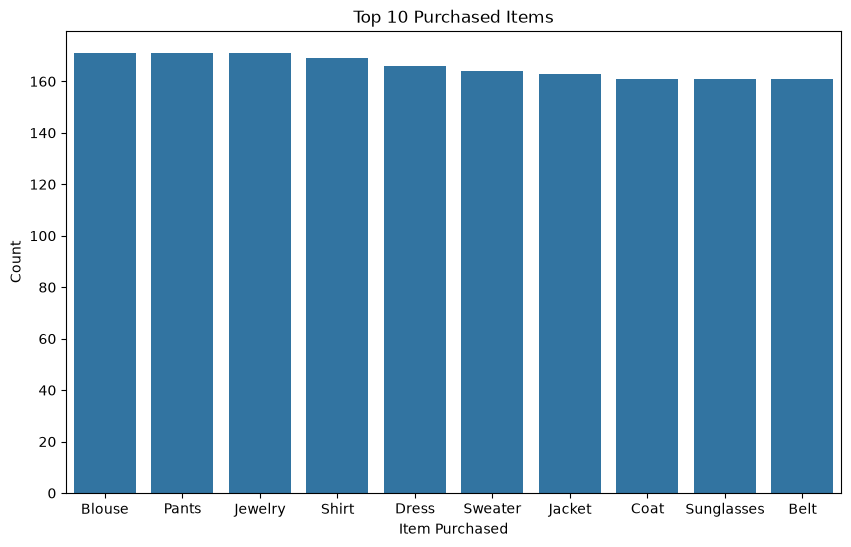

In [11]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data= df1['Item Purchased'].value_counts().head(10)
)
plt.title('Top 10 Purchased Items')
plt.xlabel('Item Purchased')
plt.ylabel ('Count')
plt.show()
# df1['Item Purchased'].value_counts().head(10).plot(kind='bar')


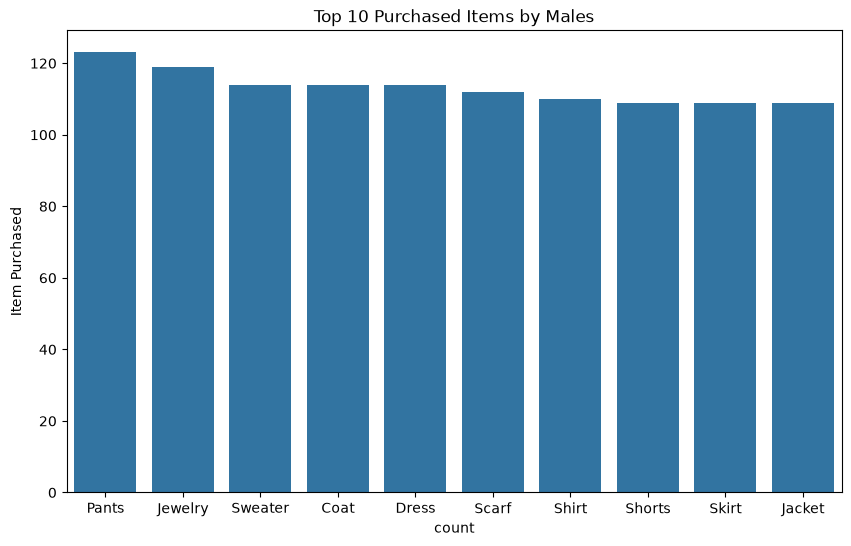

In [12]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data= male_df['Item Purchased'].value_counts().head(10)
)
plt.title('Top 10 Purchased Items by Males')
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

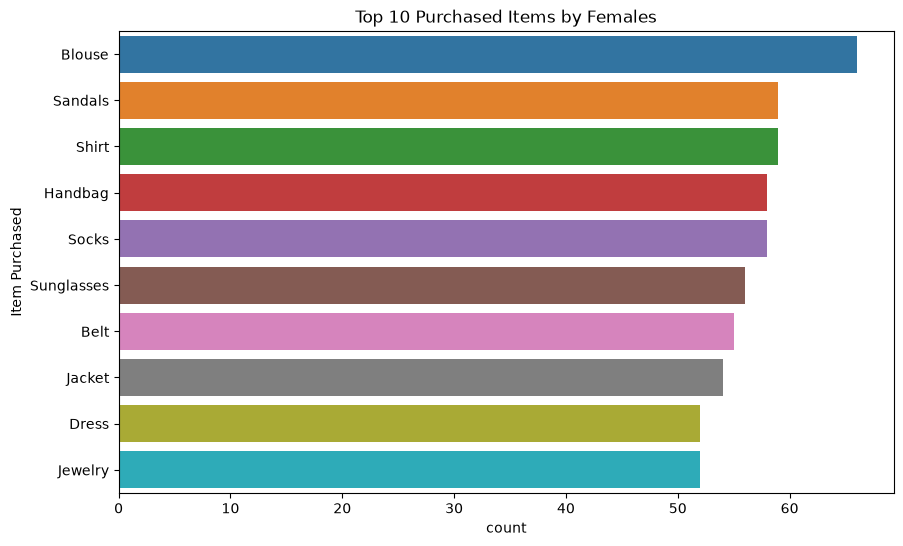

In [13]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
female_top10 = female_df['Item Purchased'].value_counts().head(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    data= female_top10,
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


In [14]:
# TODO: count Size with value_counts() for all customers
df1['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [15]:
# TODO: count Size with value_counts() for male_df and female_df
print('Male: \n', male_df['Size'].value_counts().reset_index())
print()
print('Female: \n', female_df['Size'].value_counts().reset_index())

Male: 
   Size  count
0    M   1165
1    L    716
2    S    476
3   XL    295

Female: 
   Size  count
0    M    590
1    L    337
2    S    187
3   XL    134


### **Category**

In [16]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df1['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [17]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
display('Male: ', male_df['Category'].value_counts().reset_index())
display('Female: ',female_df['Category'].value_counts().reset_index())


'Male: '

,Category,count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


'Female: '

,Category,count
0,Clothing,556
1,Accessories,392
2,Footwear,199
3,Outerwear,101


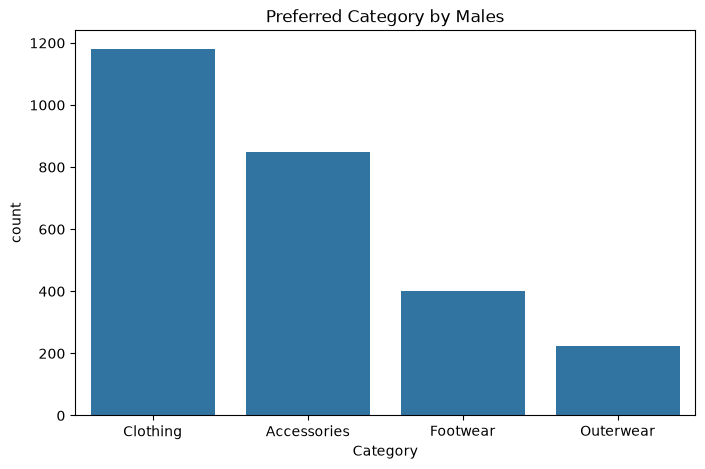

In [18]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data= male_df['Category'].value_counts()
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

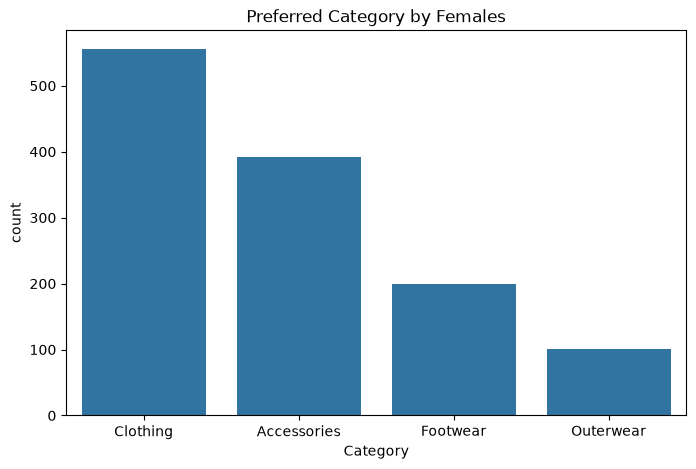

In [19]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data= female_df['Category'].value_counts()
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

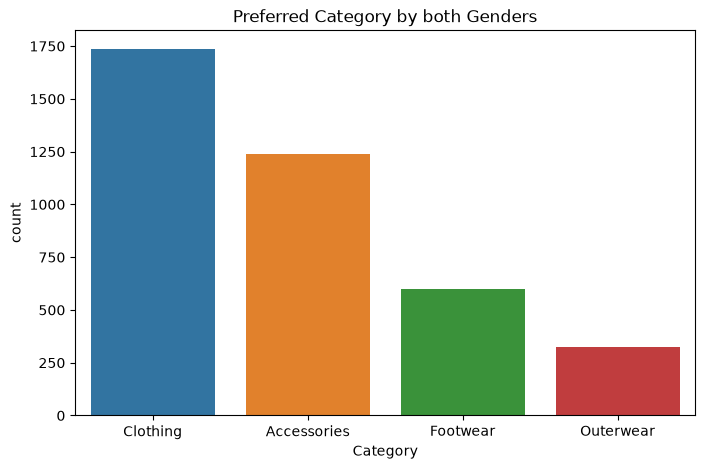

In [20]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [21]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())


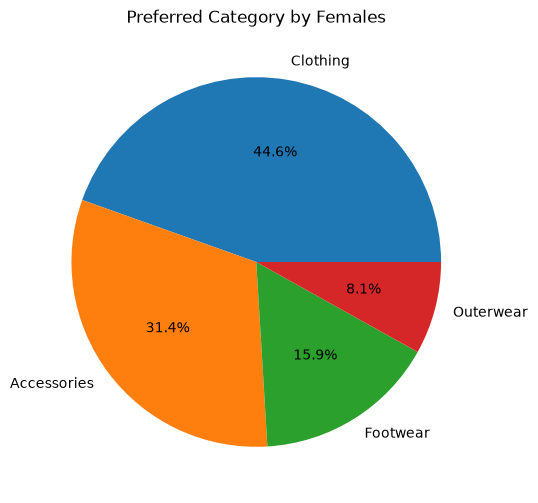

In [22]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
   waffle_data_f.values(),
   labels= waffle_data_f.keys(),
   autopct='%.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

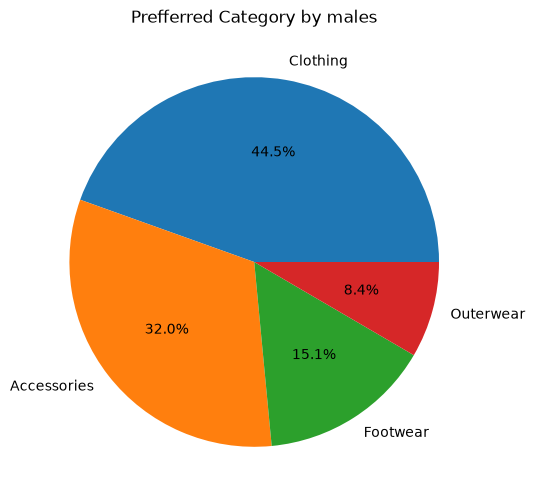

In [23]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%.1f%%'

)
plt.title('Prefferred Category by males')
plt.show()

### **Review ratings**

In [32]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

In [31]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()


In [35]:
# avg_cr_m,avg_cr_f
print(f'Average reviews rating for Female: {avg_cr_f:.2f}')
print(f'Average reviews rating for Male: {avg_cr_m:.2f}')

Average reviews rating for Female: 3.70
Average reviews rating for Male: 3.73


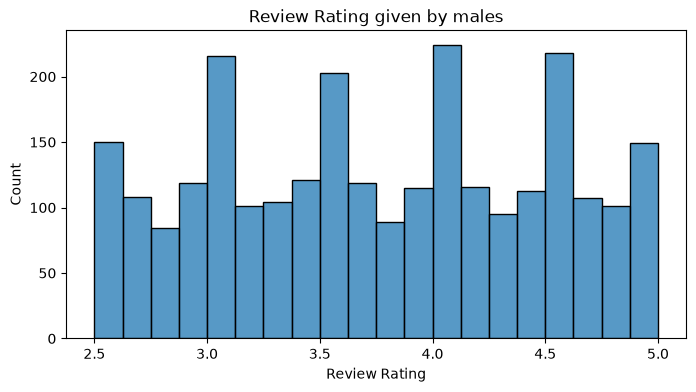

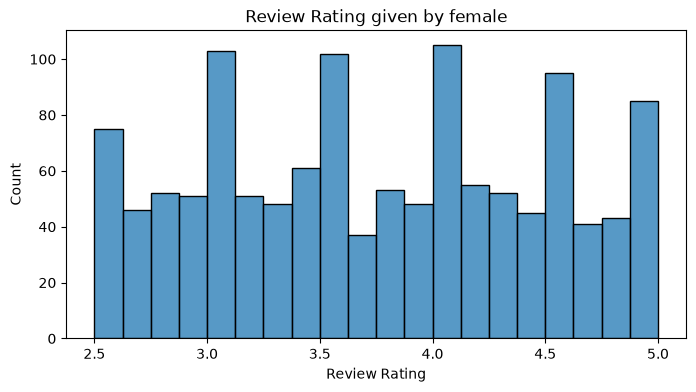

In [36]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title('Review Rating given by female')
plt.show()

In [38]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
print(cr_m['Review Rating'].value_counts().reset_index())

    Review Rating  count
0             3.7     61
1             3.4     59
2             2.7     55
3             2.9     55
4             4.0     52
5             4.2     52
6             3.9     52
7             3.3     49
8             3.0     49
9             4.9     48
10            4.1     48
11            3.5     48
12            3.1     46
13            4.7     46
14            4.6     46
15            3.6     46
16            4.8     46
17            2.6     45
18            4.3     45
19            4.4     43
20            3.2     41
21            2.8     41
22            3.8     39
23            4.5     36
24            2.5     17
25            5.0     16


### **Purchase Amount (USD)**

In [48]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()
print('Total purchase amount for male customers: ',m_tpa, 'USD')
# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
print('Total purchase amount for female customers: ',f_tpa, 'USD')


Total purchase amount for male customers:  157890 USD
Total purchase amount for female customers:  75191 USD


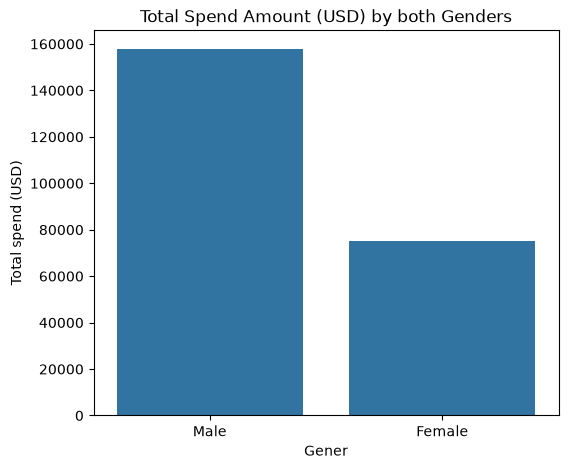

In [57]:
# TODO: plot total spend by gender with sns.barplot()
spend_gener = pd.DataFrame({
    'Gener': ['Male', 'Female'],
    'Total_Spend': [m_tpa, f_tpa]
})

plt.figure(figsize=(6, 5))
sns.barplot(
    data= spend_gener,
    x='Gener',
    y='Total_Spend'
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [60]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [61]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [69]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df1['Promo Code Used'].value_counts())
pcu

{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

                            Age  Purchase Amount (USD)  Review Rating  \
Age                    1.000000              -0.010424      -0.021949   
Purchase Amount (USD) -0.010424               1.000000       0.030776   
Review Rating         -0.021949               0.030776       1.000000   
Previous Purchases     0.040445               0.008063       0.004229   

                       Previous Purchases  
Age                              0.040445  
Purchase Amount (USD)            0.008063  
Review Rating                    0.004229  
Previous Purchases               1.000000  


(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'Age'),
  Text(1.5, 0, 'Purchase Amount (USD)'),
  Text(2.5, 0, 'Review Rating'),
  Text(3.5, 0, 'Previous Purchases')])

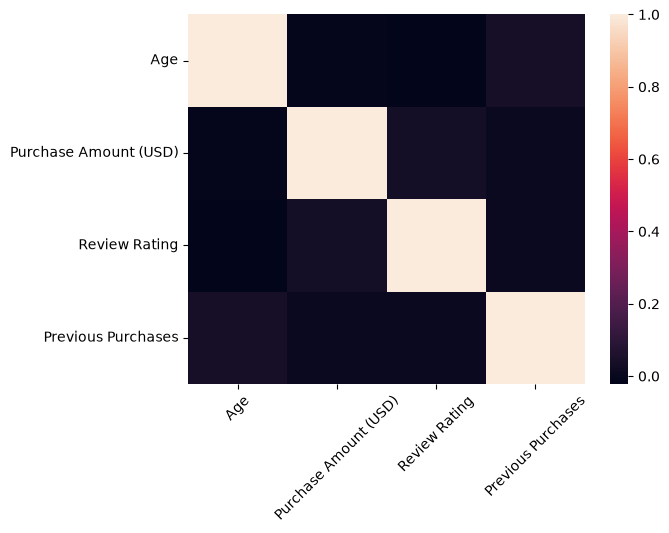

In [74]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
print(df1.corr(numeric_only=True))
sns.heatmap(
    data=df1.corr(numeric_only=True)
)
plt.xticks(rotation=45, ha='center')

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [83]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df2 = pd.get_dummies(df1, columns=['Gender', 'Size', 'Category'], dtype=int)
df2.head(5)

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [87]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [91]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df1['Purchase Amount (USD)'], bins=[20, 50, 80, float('inf')], labels=['Low', 'Medium', 'High'])
df['Amount_bin'].value_counts()

Amount_bin
Low       1462
Medium    1408
High       978
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

- The most common item for males and females are Pants and Blouse.
- The most common category for both males and females is Clothing
- Male customers spent a total of 157,890 USD, while female customers spent 75,191 USD.
- Average review rating for Female: 3.70, while average review rating for Male: 3.73
- Promo codes are not often used.


# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.